In [1]:
import torch
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
from controlnet_aux import CannyDetector
from PIL import Image
import matplotlib.pyplot as plt

/Users/brageramberg/opt/miniconda3/envs/bannergen/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/brageramberg/opt/miniconda3/envs/bannergen/lib/python3.10/site-packages/controlnet_aux/mediapipe_face/mediapipe_face_common.py:7: UserWarning: The module 'mediapipe' is not installed. The package will have limited functionality. Please install it using the command: pip install 'mediapipe'
  warnings.warn(
Unable to revert mtime: /Library/Fonts
Matplotlib is building the font cache; this may take a moment.


In [8]:
# Device setup for Apple Silicon (MPS)
device = "mps" if torch.backends.mps.is_available() else "cpu"

In [ ]:
print(f"Using device: {device}")
print(pipe.device)  # should print "mps"

# Models (compatible with SD v1.5 ControlNet) AND public unrestricted models
models = {
    "Stable Diffusion v1.5": "runwayml/stable-diffusion-v1-5",
    "Openjourney (public SD 1.5-based model)": "prompthero/openjourney"
}

# ControlNet setup (Canny edges for demo; replace with logo condition in real scenario)
controlnet = ControlNetModel.from_pretrained(
    "lllyasviel/sd-controlnet-canny",
    torch_dtype=torch.float16
).to(device)

# ControlNet auxiliary processor (Canny edge detector example)
canny = CannyDetector()



Using device: mps
mps:0


Generating images with model: Stable Diffusion v1.5


Loading pipeline components...: 100%|██████████| 6/6 [00:06<00:00,  1.05s/it]
You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
100%|██████████| 20/20 [00:20<00:00,  1.02s/it]


Generating images with model: Openjourney (public SD 1.5-based model)


Loading pipeline components...: 100%|██████████| 6/6 [00:06<00:00,  1.07s/it]
You have disabled the safety checker for <class 'diffusers.pipelines.controlnet.pipeline_controlnet.StableDiffusionControlNetPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
100%|██████████| 20/20 [00:20<00:00,  1.02s/it]


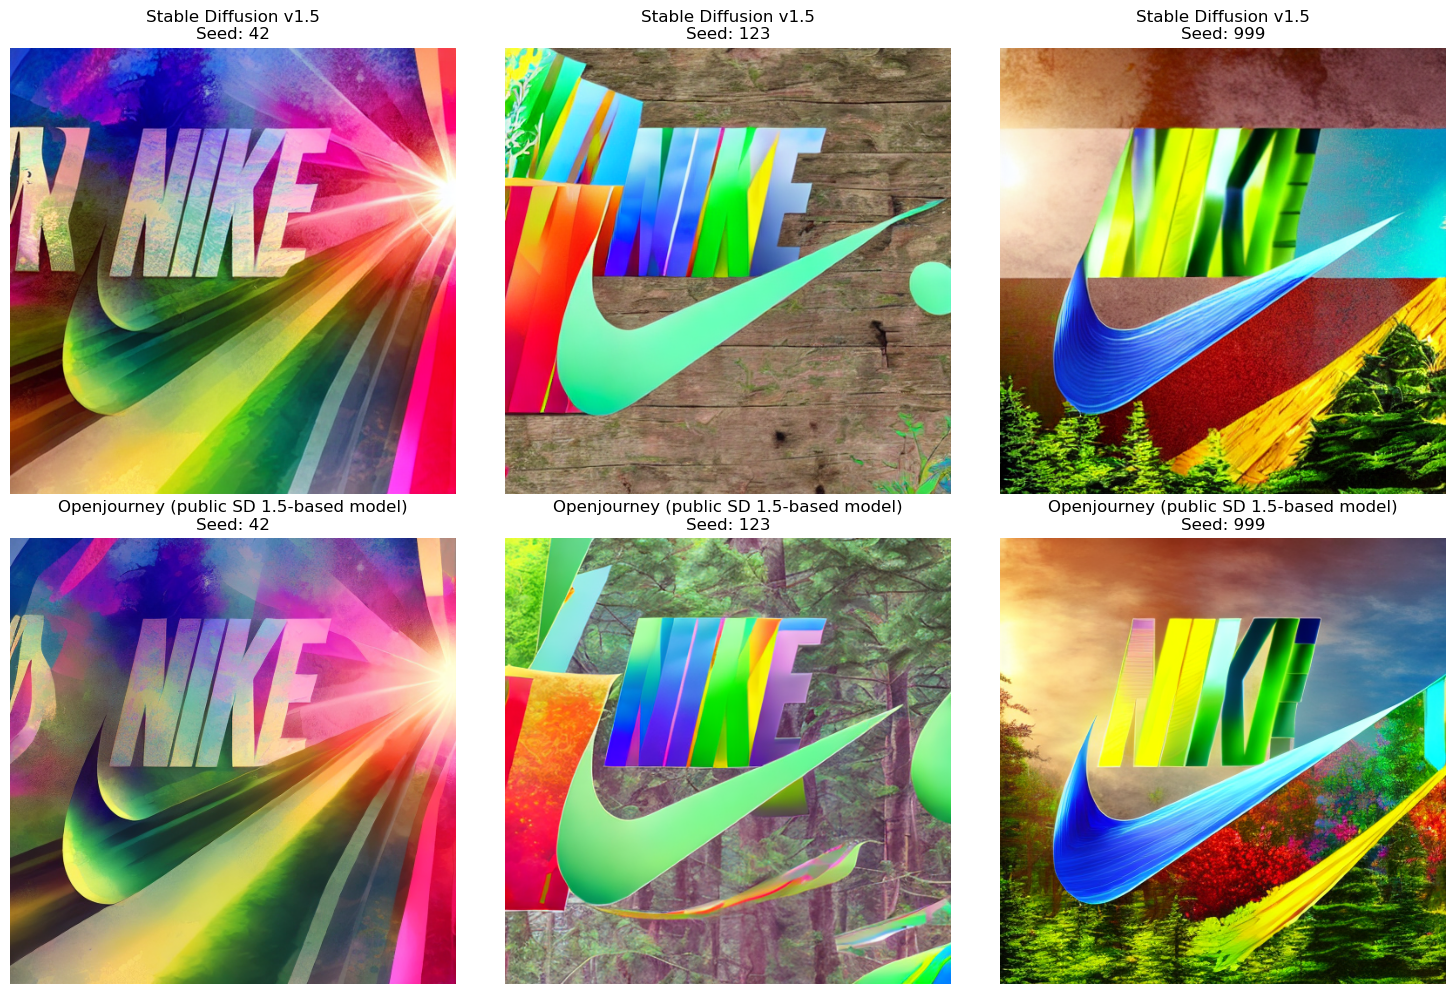

In [ ]:


# Your input/control image (logo placement mask example)
control_image = Image.open("nike.png").resize((512, 512))
control_image = canny(control_image)

# Prompt setup
prompt = "A banner image of a summer forest, vibrant colors"

# Seeds to test reproducibility and diversity
seeds = [42, 123, 999]

# Generate and store images for each model and seed
results = {}

for model_name, model_path in models.items():
    print(f"Generating images with model: {model_name}")
    
    # Setup pipeline for each model
    pipe = StableDiffusionControlNetPipeline.from_pretrained(
        model_path,
        controlnet=controlnet,
        torch_dtype=torch.float16,
        safety_checker=None  # Optional, disables NSFW checker
    ).to(device)
    
    model_images = []
    for seed in seeds:
        generator = torch.manual_seed(seed)
        
        image = pipe(
            prompt,
            num_inference_steps=20,  # Adjust for speed vs quality
            guidance_scale=7.5,
            image=control_image,
            generator=generator
        ).images[0]

        model_images.append(image)

    results[model_name] = model_images

# Plot results
fig, axes = plt.subplots(len(models), len(seeds), figsize=(5 * len(seeds), 5 * len(models)))

for i, (model_name, images) in enumerate(results.items()):
    for j, img in enumerate(images):
        ax = axes[i, j] if len(models) > 1 else axes[j]
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"{model_name}\nSeed: {seeds[j]}")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300)
plt.show()